In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [3]:
data=r"C:\Users\Casper\OneDrive\Masaüstü\verimadenciligi"

In [5]:
#Egitim (train)data
train_file=os.path.join(data,"cell2celltrain.csv")
df_train=pd.read_csv(train_file)

#test data
test_file=os.path.join(data,"cell2cellholdout.csv")
df_holdout=pd.read_csv(test_file)

print("Egitim veri seti boyutu",df_train.shape)
print("Test veri seti boyutu",df_holdout.shape)



Egitim veri seti boyutu (51047, 58)
Test veri seti boyutu (20000, 58)


In [7]:
df=df_train.copy()

In [9]:
print("Veri seti boyutu (satır, sütun):", df.shape)
print("Toplam gözlem sayısı:", df.shape[0])
print("Toplam feature sayısı:", df.shape[1] - 1)  # label hariç


Veri seti boyutu (satır, sütun): (51047, 58)
Toplam gözlem sayısı: 51047
Toplam feature sayısı: 57


In [11]:
# ================================
# (b) LABEL SAYISI VE DAĞILIMI
# ================================

print("📌 Sınıf (label) sayısı:", df_train['Churn'].nunique())

print("\n📌 Label dağılımı (adet):")
label_counts = df_train['Churn'].value_counts()
print(label_counts)


📌 Sınıf (label) sayısı: 2

📌 Label dağılımı (adet):
Churn
No     36336
Yes    14711
Name: count, dtype: int64


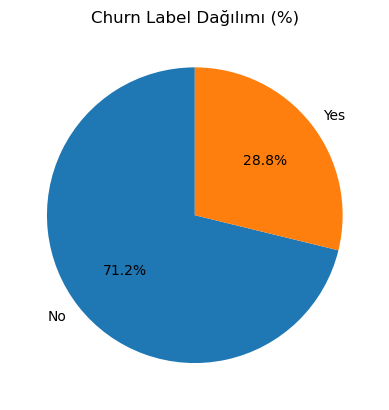

In [13]:
plt.figure()
label_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    labels=['No', 'Yes']
)
plt.title("Churn Label Dağılımı (%)")
plt.ylabel("")
plt.show()


In [15]:
from sklearn.model_selection import StratifiedKFold

X = df_train.drop('Churn', axis=1)
y = df_train['Churn']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    break

print("Train sınıf oranları:")
print(y_train.value_counts(normalize=True))

print("Test sınıf oranları:")
print(y_test.value_counts(normalize=True))

Train sınıf oranları:
Churn
No     0.71183
Yes    0.28817
Name: proportion, dtype: float64
Test sınıf oranları:
Churn
No     0.711753
Yes    0.288247
Name: proportion, dtype: float64


In [17]:
df.head()


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [21]:
# 2. Tekrar Eden Kayıtların Analizi
print("2.1 Tüm Sütunlarda Tekrar Eden Kayıtlar:")
print("-"*50)
duplicates = df_train.duplicated().sum()
print(f"Toplam Tekrar Eden Kayıt Sayısı: {duplicates}")
print(f"Tekrar Eden Kayıt Yüzdesi: {(duplicates/len(df_train)*100):.2f}%")

print("\n2.2 Sütunlara Göre Tekrar Eden Değerler:")
print("-"*50)
for col in df_train.columns:
    n_unique = df_train[col].nunique()
    n_duplicates = len(df_train) - n_unique
    dup_percentage = (n_duplicates/len(df_train)*100)
    print(f"{col:25}: {n_unique:,} benzersiz değer, {dup_percentage:.2f}% tekrar oranı")

2.1 Tüm Sütunlarda Tekrar Eden Kayıtlar:
--------------------------------------------------
Toplam Tekrar Eden Kayıt Sayısı: 0
Tekrar Eden Kayıt Yüzdesi: 0.00%

2.2 Sütunlara Göre Tekrar Eden Değerler:
--------------------------------------------------
CustomerID               : 51,047 benzersiz değer, 0.00% tekrar oranı
Churn                    : 2 benzersiz değer, 100.00% tekrar oranı
MonthlyRevenue           : 12,665 benzersiz değer, 75.19% tekrar oranı
MonthlyMinutes           : 2,719 benzersiz değer, 94.67% tekrar oranı
TotalRecurringCharge     : 214 benzersiz değer, 99.58% tekrar oranı
DirectorAssistedCalls    : 146 benzersiz değer, 99.71% tekrar oranı
OverageMinutes           : 746 benzersiz değer, 98.54% tekrar oranı
RoamingCalls             : 530 benzersiz değer, 98.96% tekrar oranı
PercChangeMinutes        : 2,262 benzersiz değer, 95.57% tekrar oranı
PercChangeRevenues       : 2,899 benzersiz değer, 94.32% tekrar oranı
DroppedCalls             : 285 benzersiz değer, 99.44% te

In [23]:
# Sayısal ve kategorik sütunları belirle
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Sayısal sütun sayısı:", len(numeric_cols))
print("Kategorik sütun sayısı:", len(categorical_cols))

print("\n🔸 Sayısal sütun örnekleri:")
print(numeric_cols[:10])

print("\n🔹 Kategorik sütun örnekleri:")
print(categorical_cols[:10])

Sayısal sütun sayısı: 35
Kategorik sütun sayısı: 23

🔸 Sayısal sütun örnekleri:
['CustomerID', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls']

🔹 Kategorik sütun örnekleri:
['Churn', 'ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers']


In [25]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,51047.0,3.201957e+06,116905.561666,3000002.00,3100632.00,3201534.00,3305376.000,3399994.00
MonthlyRevenue,50891.0,5.883449e+01,44.507336,-6.17,33.61,48.46,71.065,1223.38
MonthlyMinutes,50891.0,5.256534e+02,529.871063,0.00,158.00,366.00,723.000,7359.00
TotalRecurringCharge,50891.0,4.683009e+01,23.848871,-11.00,30.00,45.00,60.000,400.00
DirectorAssistedCalls,50891.0,8.952290e-01,2.228546,0.00,0.00,0.25,0.990,159.39
OverageMinutes,50891.0,4.002778e+01,96.588076,0.00,0.00,3.00,41.000,4321.00
RoamingCalls,50891.0,1.236244e+00,9.818294,0.00,0.00,0.00,0.300,1112.40
PercChangeMinutes,50680.0,-1.154791e+01,257.514772,-3875.00,-83.00,-5.00,66.000,5192.00
PercChangeRevenues,50680.0,-1.191985e+00,39.574915,-1107.70,-7.10,-0.30,1.600,2483.50
DroppedCalls,51047.0,6.011489e+00,9.043955,0.00,0.70,3.00,7.700,221.70


In [27]:
# Kayıp (Null/NaN) değerlerin sayısını hesaplama
missing_counts = df_train.isnull().sum()
print(missing_counts)

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

In [29]:
total_rows=len(df_train)
missing_percentage=(missing_counts[missing_counts>0]/total_rows)*100

missing_data_summary = pd.DataFrame({
    'Kayıp Sayısı': missing_counts[missing_counts > 0],
    'Kayıp Yüzdesi (%)': missing_percentage.round(2)
}).sort_values(by='Kayıp Yüzdesi (%)', ascending=False)

print(missing_data_summary)

                       Kayıp Sayısı  Kayıp Yüzdesi (%)
AgeHH1                          909               1.78
AgeHH2                          909               1.78
PercChangeMinutes               367               0.72
PercChangeRevenues              367               0.72
MonthlyRevenue                  156               0.31
MonthlyMinutes                  156               0.31
TotalRecurringCharge            156               0.31
DirectorAssistedCalls           156               0.31
OverageMinutes                  156               0.31
RoamingCalls                    156               0.31
ServiceArea                      24               0.05
Handsets                          1               0.00
HandsetModels                     1               0.00
CurrentEquipmentDays              1               0.00


In [31]:
# Eksik değer doldurma (uyarı vermeyen sürüm)

# Kategorik sütun: mode ile doldur
df_train['ServiceArea'] = df_train['ServiceArea'].fillna(df_train['ServiceArea'].mode()[0])
df_holdout['ServiceArea'] = df_holdout['ServiceArea'].fillna(df_train['ServiceArea'].mode()[0])

# Sayısal sütunlar: mean ile doldur
num_cols_to_fill = [
    'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 
    'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
    'PercChangeMinutes', 'PercChangeRevenues',
    'AgeHH1', 'AgeHH2',
    'Handsets', 'HandsetModels', 'CurrentEquipmentDays'
]

for col in num_cols_to_fill:
    df_train[col] = df_train[col].fillna(df_train[col].mean())
    df_holdout[col] = df_holdout[col].fillna(df_train[col].mean())

# Kontrol
print("Kalan eksik değer sayısı:", df_train.isnull().sum().sum())


Kalan eksik değer sayısı: 0


In [33]:
from sklearn.preprocessing import LabelEncoder

# Hedef değişkeni (Churn): Yes/No → 1/0
df_train['Churn'] = df_train['Churn'].map({'Yes': 1, 'No': 0})
df_holdout['Churn'] = df_holdout['Churn'].map({'Yes': 1, 'No': 0})

# Kategorik sütunları bul
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()
print("Dönüştürülecek kategorik sütunlar:", categorical_cols)

# Label Encoding (train + holdout birlikte)
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_holdout[col]], axis=0).astype(str)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col].astype(str))
    df_holdout[col] = le.transform(df_holdout[col].astype(str))

print("\n✅ Kodlama tamamlandı, artık tüm veriler sayısal.")
print(df_train.dtypes.head(10))

Dönüştürülecek kategorik sütunlar: ['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']

✅ Kodlama tamamlandı, artık tüm veriler sayısal.
CustomerID                 int64
Churn                      int64
MonthlyRevenue           float64
MonthlyMinutes           float64
TotalRecurringCharge     float64
DirectorAssistedCalls    float64
OverageMinutes           float64
RoamingCalls             float64
PercChangeMinutes        float64
PercChangeRevenues       float64
dtype: object


In [35]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [37]:

if 'CustomerID' in df.columns:
    df=df.drop(columns=['CustomerID'])
    print("Customer ID kaldirildi")



Customer ID kaldirildi


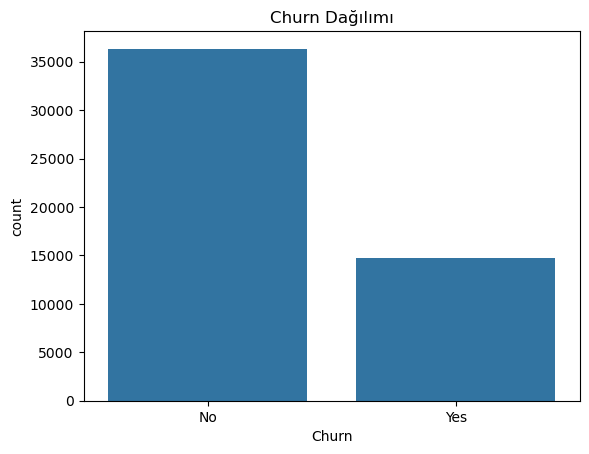

In [39]:
sns.countplot(x='Churn', data=df_train)
plt.xticks([0,1], ['No','Yes'])
plt.title('Churn Dağılımı')
plt.show()


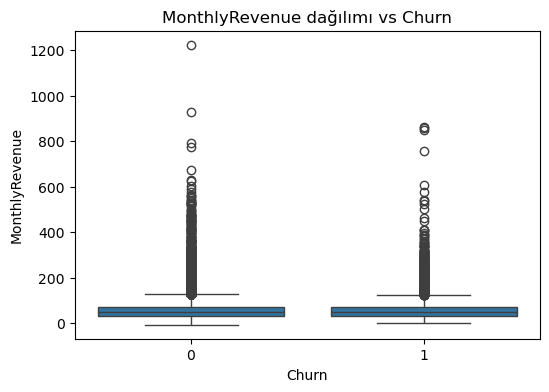

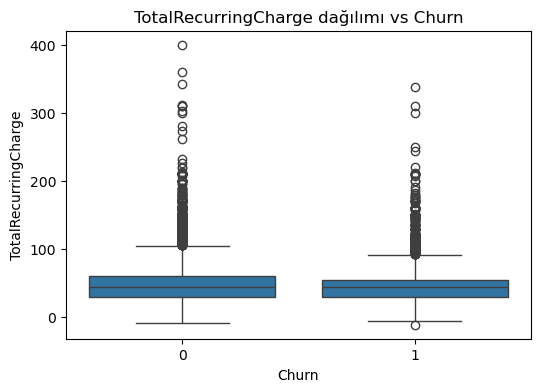

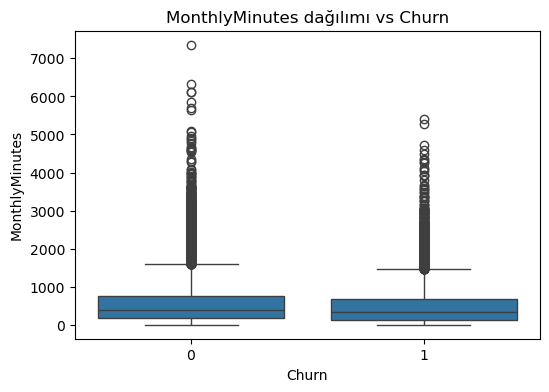

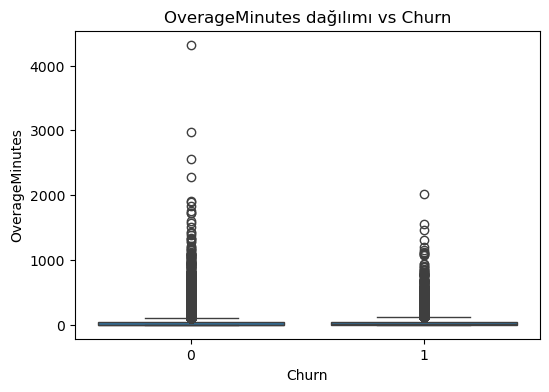

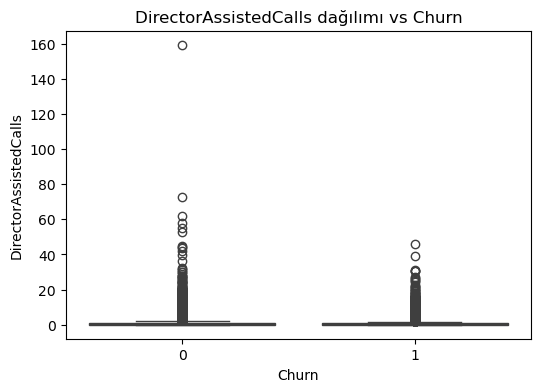

In [41]:
num_cols_critical = ['MonthlyRevenue','TotalRecurringCharge','MonthlyMinutes','OverageMinutes','DirectorAssistedCalls']

for col in num_cols_critical:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df_train)
    plt.title(f'{col} dağılımı vs Churn')
    plt.show()


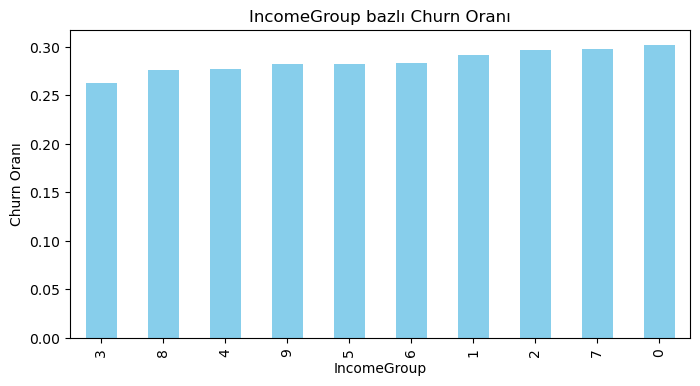

In [42]:
income_churn = df_train.groupby('IncomeGroup')['Churn'].mean().sort_values()
income_churn.plot(kind='bar', figsize=(8,4), color='skyblue')
plt.ylabel('Churn Oranı')
plt.title('IncomeGroup bazlı Churn Oranı')
plt.show()


In [45]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

%matplotlib inline

In [47]:
#  Veri Hazırlığı
# X ve y
X = df_train.drop(columns=['Churn', 'CustomerID'])
y = df_train['Churn']


In [49]:
# ------------------------
best_k = 25  # Seçilecek feature sayısı
selector = SelectKBest(score_func=mutual_info_classif, k=best_k)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

# Seçilen feature’ları DataFrame olarak göster
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
print(f"\n🔹 Seçilen Feature Sayısı: {len(selected_features)}")
print("\n🔹 Seçilen Feature Listesi:")
print(list(selected_features))
X_selected_df.head()


🔹 Seçilen Feature Sayısı: 25

🔹 Seçilen Feature Listesi:
['MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'RoamingCalls', 'PercChangeRevenues', 'UnansweredCalls', 'InboundCalls', 'PeakCallsInOut', 'CallWaitingCalls', 'MonthsInService', 'ActiveSubs', 'HandsetModels', 'CurrentEquipmentDays', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'HasCreditCard', 'IncomeGroup', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'Occupation', 'MaritalStatus']


,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeRevenues,UnansweredCalls,InboundCalls,PeakCallsInOut,CallWaitingCalls,MonthsInService,...,TruckOwner,BuysViaMailOrder,RespondsToMailOffers,HasCreditCard,IncomeGroup,HandsetPrice,MadeCallToRetentionTeam,CreditRating,Occupation,MaritalStatus
0,219.0,22.0,0.25,0.0,-19.0,6.3,0.0,58.0,0.3,61.0,...,0.0,1.0,1.0,1.0,4.0,8.0,1.0,0.0,4.0,0.0
1,10.0,17.0,0.00,0.0,0.0,2.7,0.0,5.0,0.0,58.0,...,0.0,1.0,1.0,1.0,5.0,8.0,0.0,3.0,4.0,2.0
2,8.0,38.0,0.00,0.0,0.0,0.0,0.0,1.3,0.0,60.0,...,0.0,0.0,0.0,1.0,6.0,15.0,0.0,2.0,1.0,2.0
3,1312.0,75.0,1.24,0.0,8.1,76.0,147.0,555.7,22.7,59.0,...,0.0,1.0,1.0,1.0,6.0,0.0,0.0,3.0,3.0,0.0
4,0.0,17.0,0.00,0.0,-0.2,0.0,0.0,0.0,0.0,53.0,...,0.0,1.0,1.0,1.0,9.0,0.0,0.0,0.0,4.0,2.0


C:\Users\Casper\AppData\Local\Temp\ipykernel_24848\2241319201.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores_series.index, y=mi_scores_series.values, palette='viridis')


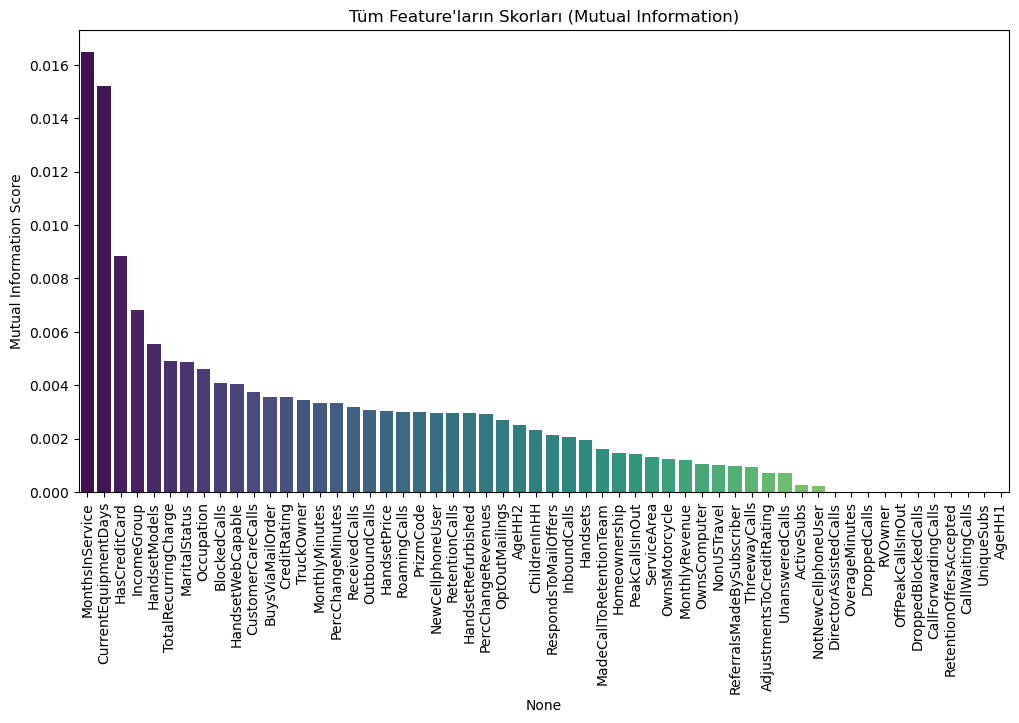

In [50]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# X: feature matrix, y: label
mi_scores = mutual_info_classif(X, y, random_state=42)

# Series'e çevir
mi_scores_series = pd.Series(mi_scores, index=X.columns)

# Büyükten küçüğe sırala
mi_scores_series = mi_scores_series.sort_values(ascending=False)

# Skorları görselleştir
plt.figure(figsize=(12,6))
sns.barplot(x=mi_scores_series.index, y=mi_scores_series.values, palette='viridis')
plt.xticks(rotation=90)
plt.ylabel("Mutual Information Score")
plt.title("Tüm Feature'ların Skorları (Mutual Information)")
plt.show()


In [52]:
# DataFrame olarak göstermek
X_final_df = pd.DataFrame(X, columns=selected_features)
display(X_final_df.head())



,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeRevenues,UnansweredCalls,InboundCalls,PeakCallsInOut,CallWaitingCalls,MonthsInService,...,TruckOwner,BuysViaMailOrder,RespondsToMailOffers,HasCreditCard,IncomeGroup,HandsetPrice,MadeCallToRetentionTeam,CreditRating,Occupation,MaritalStatus
0,219.0,22.0,0.25,0.0,-19.0,6.3,0.0,58.0,0.3,61,...,0,1,1,1,4,8,1,0,4,0
1,10.0,17.0,0.00,0.0,0.0,2.7,0.0,5.0,0.0,58,...,0,1,1,1,5,8,0,3,4,2
2,8.0,38.0,0.00,0.0,0.0,0.0,0.0,1.3,0.0,60,...,0,0,0,1,6,15,0,2,1,2
3,1312.0,75.0,1.24,0.0,8.1,76.0,147.0,555.7,22.7,59,...,0,1,1,1,6,0,0,3,3,0
4,0.0,17.0,0.00,0.0,-0.2,0.0,0.0,0.0,0.0,53,...,0,1,1,1,9,0,0,0,4,2


In [55]:
# 🔹 Ortak feature'ları bulma
kbest_features = [
    'CustomerID', 'MonthlyMinutes', 'TotalRecurringCharge', 'PercChangeMinutes', 
    'PercChangeRevenues', 'BlockedCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut',
    'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'CurrentEquipmentDays', 
    'HandsetWebCapable', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'HasCreditCard',
    'RetentionCalls', 'AdjustmentsToCreditRating', 'HandsetPrice', 'CreditRating', 'Occupation', 'MaritalStatus'
]

rf_features = [
    "MonthsinService","CurrentEquipmentDays","CreditRating", "DirectorAssistedCalls","TotalRecurringCharge", "MonthlyMinutes","PercChangeMinutes","BlockedCalls",
    "ServiceArea","MonthlyRevenue","UniqueSubs","AverageMinutes", "PercChangeRevenue","RoamingCalls","PeakCallsInOut",
    "IncomeGroup", "OffPeakCallsInOut","ReceivedCalls","OutboundCalls","UnansweredCalls", "DroppedCalls","AgeHH1","DroppedBlockedCalls",
    "InboundCalls","CallWaitingCalls","HandsetModels","CustomerCareCalls","PrizmCodes","HandsetPrice"
]

rfe_features = [
    'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'OverageMinutes', 'PercChangeMinutes', 'PercChangeRevenues',
    'DroppedCalls', 'BlockedCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
    'PeakCallsInOut', 'DroppedBlockedCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'CurrentEquipmentDays',
    'AgeHH1', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'RespondsToMailOffers', 'HasCreditCard', 'RetentionCalls',
    'RetentionOffersAccepted', 'IncomeGroup', 'AdjustmentsToCreditRating', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating'
]
lasso_features = [
    'MonthlyRevenue','MonthlyMinutes','TotalRecurringCharge','OverageMinutes','PercChangeMinutes','PercChangeRevenues','DroppedCalls','BlockedCalls',
    'CustomerCareCalls','ThreewayCalls','OutboundCalls','PeakCallsInOut','DroppedBlockedCalls','MonthsInService','UniqueSubs','ActiveSubs','Handsets','CurrentEquipmentDays','AgeHH1',
    'ChildrenInHH','HandsetRefurbished','RespondsToMailOffers','HasCreditCard','IncomeGroup','AdjustmentsToCreditRating','HandsetPrice','MadeCallToRetentionTeam','CreditRating'
]


In [57]:
from sklearn.decomposition import TruncatedSVD

# ------------------------
# SVD ile boyut indirgeme
# X_selected_df: SelectKBest ile seçilen feature'lar

# SVD boyutu (istediğin boyut sayısı)
n_components = 10  

svd = TruncatedSVD(n_components=n_components, random_state=42)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected_df)
X_svd = svd.fit_transform(X_scaled)


# SVD sonrası DataFrame oluştur
X_svd_df = pd.DataFrame(X_svd, columns=[f"SVD_Component_{i+1}" for i in range(n_components)])
print("\n🔹 SVD Sonrası Veri Boyutu:", X_svd_df.shape)
display(X_svd_df.head())

# Açıklanan varyans oranı
explained_variance = svd.explained_variance_ratio_
print("\n🔹 Açıklanan Varyans Oranları:")
for i, var in enumerate(explained_variance, 1):
    print(f"Component {i}: {var:.4f}")

# Artık X_svd_df ile downstream modellerini kullanabilirsin



🔹 SVD Sonrası Veri Boyutu: (51047, 10)


,SVD_Component_1,SVD_Component_2,SVD_Component_3,SVD_Component_4,SVD_Component_5,SVD_Component_6,SVD_Component_7,SVD_Component_8,SVD_Component_9,SVD_Component_10
0,-1.514321,1.588379,3.496333,1.351545,-2.291248,0.110049,-0.481981,-0.626567,3.967992,2.290870
1,-3.710858,1.535197,1.677404,4.761628,-1.957290,-0.684817,0.653766,1.717789,-0.736492,-0.604413
2,-3.258905,-0.487618,1.578656,6.630092,-0.990833,-0.329439,0.326475,-1.535156,-2.074163,-0.346437
3,6.875171,5.450955,1.488964,3.283141,1.356283,-1.218881,0.937818,-0.064867,1.121686,-2.237439
4,-3.006006,2.931808,3.671012,2.831610,0.115563,-0.060709,0.247160,1.391108,-0.322775,-0.553097



🔹 Açıklanan Varyans Oranları:
Component 1: 0.1921
Component 2: 0.1207
Component 3: 0.0725
Component 4: 0.0657
Component 5: 0.0446
Component 6: 0.0431
Component 7: 0.0410
Component 8: 0.0391
Component 9: 0.0388
Component 10: 0.0377


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# y hedef değişken
y = df_train['Churn']

# Train-test split (stratify önemli)
X_train, X_test, y_train, y_test = train_test_split(
    X_svd_df, y, test_size=0.2, random_state=42, stratify=y
)

# Model oluştur
nb_model = GaussianNB()

# Eğit
nb_model.fit(X_train, y_train)

# Tahmin
y_pred = nb_model.predict(X_test)

# Sonuçlar
print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 F1-score:", f1_score(y_test, y_pred))
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


🔹 Accuracy: 0.6992164544564152
🔹 F1-score: 0.14001680201624195

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.95      0.82      7268
           1       0.40      0.08      0.14      2942

    accuracy                           0.70     10210
   macro avg       0.56      0.52      0.48     10210
weighted avg       0.63      0.70      0.62     10210


🔹 Confusion Matrix:
 [[6889  379]
 [2692  250]]


In [61]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [62]:
# NN Modeli
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_svd_df.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    BatchNormalization(),
    
    Dense(1, activation='sigmoid')   # Churn = Binary (0/1)
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

C:\Users\Casper\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 224 (896.00 B)

In [65]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping tanımla
early = EarlyStopping(
    monitor='val_loss',    # Hangi metriği izleyecek
    patience=10,           # Kaç epoch boyunca iyileşme olmazsa duracak
    restore_best_weights=True
)

# NN eğitimi
history = nn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early],  # Şimdi tanımlı
    verbose=1
)


Epoch 1/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6475 - loss: 0.6625 - val_accuracy: 0.7121 - val_loss: 0.5930
Epoch 2/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7101 - loss: 0.5980 - val_accuracy: 0.7119 - val_loss: 0.5909
Epoch 3/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7170 - loss: 0.5891 - val_accuracy: 0.7117 - val_loss: 0.5905
Epoch 4/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7115 - loss: 0.5931 - val_accuracy: 0.7119 - val_loss: 0.5904
Epoch 5/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7135 - loss: 0.5885 - val_accuracy: 0.7119 - val_loss: 0.5890
Epoch 6/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7144 - loss: 0.5876 - val_accuracy: 0.7117 - val_loss: 0.5887
Epoch 7/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7101 - loss: 0.5907 - val_accuracy: 0.7122 - val_loss: 0.5870
Epoch 8/50
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7123 - loss: 0.58

In [67]:

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred_prob = nn_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("🔹 Neural Network Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 Neural Network F1-score:", f1_score(y_test, y_pred))
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
🔹 Neural Network Accuracy: 0.7122428991185112
🔹 Neural Network F1-score: 0.048575129533678756

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.99      0.83      7268
           1       0.51      0.03      0.05      2942

    accuracy                           0.71     10210
   macro avg       0.61      0.51      0.44     10210
weighted avg       0.66      0.71      0.61     10210


🔹 Confusion Matrix:
 [[7197   71]
 [2867   75]]


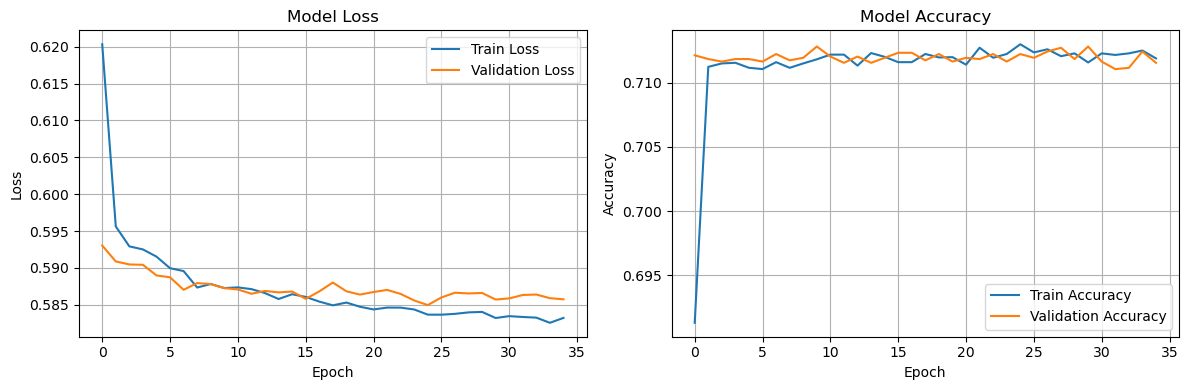

In [69]:
plt.figure(figsize=(12, 4))

# Loss Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Fitting 3 folds for each of 20 candidates, totalling 60 fits
🔹 En iyi hiperparametreler: {'n_estimators': 150, 'learning_rate': 0.1, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': 3}
🎯 Seçilen threshold: 0.204
Model     : AdaBoost
Accuracy  : 0.5161
Precision : 0.3351
Recall    : 0.6903
F1        : 0.4512
AUC       : 0.5878

📌 Classification Report

              precision    recall  f1-score   support

No Churn (0)       0.78      0.45      0.57      7268
   Churn (1)       0.34      0.69      0.45      2942

    accuracy                           0.52     10210
   macro avg       0.56      0.57      0.51     10210
weighted avg       0.65      0.52      0.53     10210



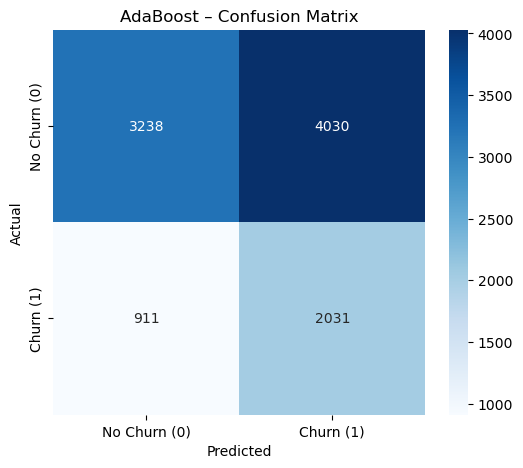

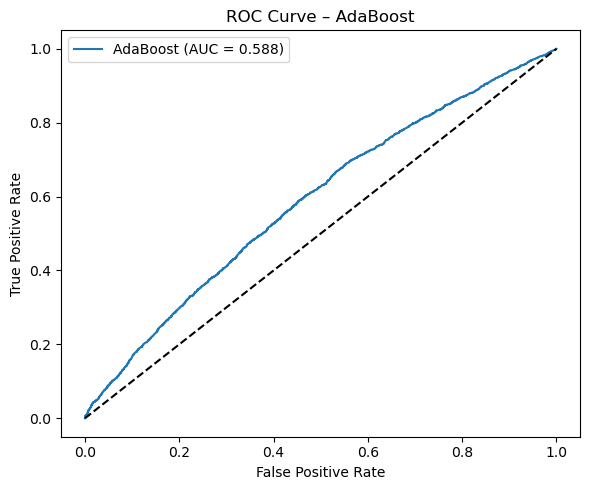

In [71]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================
# 1️⃣ Base AdaBoost Model
# ==============================
ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

# ==============================
# 2️⃣ Hiperparametre Aralıkları
# ==============================
param_dist = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3],
    'estimator__min_samples_leaf': [1, 5, 10]
}

# ==============================
# 3️⃣ RandomizedSearchCV
# ==============================
random_search = RandomizedSearchCV(
    estimator=ada_base,
    param_distributions=param_dist,
    n_iter=20,          # rastgele 20 kombinasyon dene → hızlı
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,          # tüm CPU çekirdeklerini kullan
    verbose=2,
    random_state=42
)

# Eğit
random_search.fit(X_train, y_train)

# ==============================
# 4️⃣ En iyi model & parametreler
# ==============================
ada_best = random_search.best_estimator_
print("🔹 En iyi hiperparametreler:", random_search.best_params_)

# Tahmin olasılıkları
ada_prob = ada_best.predict_proba(X_test)[:, 1]

# ROC tabanlı optimal threshold (Youden’s J)
fpr, tpr, thresholds = roc_curve(y_test, ada_prob)
best_threshold = thresholds[(tpr - fpr).argmax()]
ada_pred = (ada_prob >= best_threshold).astype(int)
print("🎯 Seçilen threshold:", round(best_threshold, 3))

# ==============================
# 5️⃣ Metrikler
# ==============================
ada_results = {
    "Model": "AdaBoost",
    "Accuracy": accuracy_score(y_test, ada_pred),
    "Precision": precision_score(y_test, ada_pred, zero_division=0),
    "Recall": recall_score(y_test, ada_pred, zero_division=0),
    "F1": f1_score(y_test, ada_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, ada_prob)
}

for k, v in ada_results.items():
    if isinstance(v, float):
        print(f"{k:10}: {v:.4f}")
    else:
        print(f"{k:10}: {v}")

print("\n📌 Classification Report\n")
print(classification_report(y_test, ada_pred, target_names=["No Churn (0)", "Churn (1)"], zero_division=0))

# ==============================
# 6️⃣ Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, ada_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)
plt.title("AdaBoost – Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ==============================
# 7️⃣ ROC Curve
# ==============================
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {ada_results['AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – AdaBoost")
plt.legend()
plt.tight_layout()
plt.show()


📌 Bagging Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.52      0.62      7268
           1       0.33      0.57      0.42      2942

    accuracy                           0.54     10210
   macro avg       0.54      0.55      0.52     10210
weighted avg       0.63      0.54      0.56     10210

✅ Bagging Results:
 {'Model': 'Bagging', 'Accuracy': 0.5363369245837414, 'Precision': 0.32675947409126066, 'Recall': 0.5744391570360299, 'F1': 0.41656396351984226, 'AUC': 0.5685454935578963}


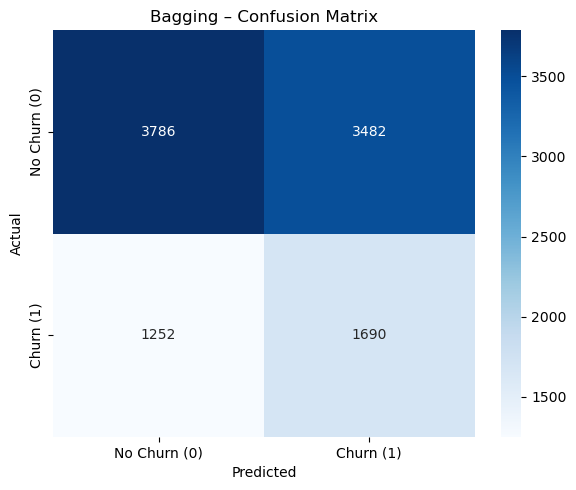

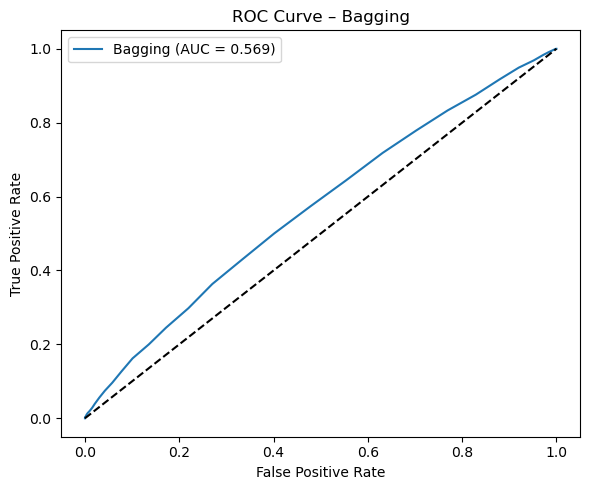

In [73]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================
# 1️⃣ Bagging Model
# ==============================
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=50,
    max_samples=0.7,
    max_features=0.7,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

# ==============================
# 2️⃣ Olasılık + Threshold
# ==============================
bag_prob = bagging.predict_proba(X_test)[:, 1]

threshold = 0.30
bag_pred = (bag_prob >= threshold).astype(int)

# ==============================
# 3️⃣ Metrikler
# ==============================
bag_auc = roc_auc_score(y_test, bag_prob)

bag_results = {
    "Model": "Bagging",
    "Accuracy": accuracy_score(y_test, bag_pred),
    "Precision": precision_score(y_test, bag_pred, zero_division=0),
    "Recall": recall_score(y_test, bag_pred, zero_division=0),
    "F1": f1_score(y_test, bag_pred, zero_division=0),
    "AUC": bag_auc
}

print("📌 Bagging Classification Report:\n")
print(classification_report(y_test, bag_pred, zero_division=0))

print("✅ Bagging Results:\n", bag_results)

# ==============================
# 4️⃣ Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, bag_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)
plt.title('Bagging – Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ==============================
# 5️⃣ ROC Curve
# ==============================
fpr, tpr, _ = roc_curve(y_test, bag_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Bagging (AUC = {bag_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Bagging")
plt.legend()
plt.tight_layout()
plt.show()


320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Model,Accuracy,Precision,Recall,F1,AUC
0,Naive Bayes,0.699216,0.397456,0.084976,0.140017,0.560058
1,Neural Network,0.712243,0.513699,0.025493,0.048575,0.611930
2,AdaBoost,0.516063,0.335093,0.690347,0.451183,0.587781
3,Bagging,0.536337,0.326759,0.574439,0.416564,0.568545


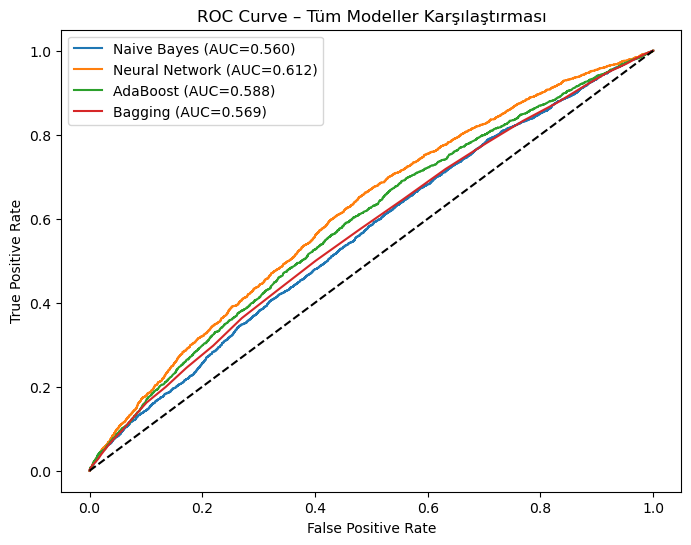

In [75]:
# ===== Naive Bayes =====
nb_prob = nb_model.predict_proba(X_test)[:,1]
nb_pred = nb_model.predict(X_test)

nb_results = {
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, nb_pred),
    "Precision": precision_score(y_test, nb_pred),
    "Recall": recall_score(y_test, nb_pred),
    "F1": f1_score(y_test, nb_pred),
    "AUC": roc_auc_score(y_test, nb_prob)
}

# ===== Neural Network =====
nn_prob = nn_model.predict(X_test).ravel()
nn_pred = (nn_prob > 0.5).astype(int)

nn_results = {
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, nn_pred),
    "Precision": precision_score(y_test, nn_pred),
    "Recall": recall_score(y_test, nn_pred),
    "F1": f1_score(y_test, nn_pred),
    "AUC": roc_auc_score(y_test, nn_prob)
}

# ===== Tablo =====
results_df = pd.DataFrame([
    nb_results,
    nn_results,
    ada_results,
    bag_results
])

display(results_df)

# ===== ROC – TÜM MODELLER =====
plt.figure(figsize=(8,6))

models_probs = {
    "Naive Bayes": nb_prob,
    "Neural Network": nn_prob,
    "AdaBoost": ada_prob,
    "Bagging": bag_prob
}

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve – Tüm Modeller Karşılaştırması")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


Epoch 1/50 - Train Loss: 0.9855 - Val Loss: 0.9733
Epoch 2/50 - Train Loss: 0.9756 - Val Loss: 0.9709
Epoch 3/50 - Train Loss: 0.9720 - Val Loss: 0.9685
Epoch 4/50 - Train Loss: 0.9678 - Val Loss: 0.9680
Epoch 5/50 - Train Loss: 0.9666 - Val Loss: 0.9665
Epoch 6/50 - Train Loss: 0.9649 - Val Loss: 0.9635
Epoch 7/50 - Train Loss: 0.9644 - Val Loss: 0.9635
Epoch 8/50 - Train Loss: 0.9630 - Val Loss: 0.9633
Epoch 9/50 - Train Loss: 0.9621 - Val Loss: 0.9632
Epoch 10/50 - Train Loss: 0.9624 - Val Loss: 0.9630
Epoch 11/50 - Train Loss: 0.9608 - Val Loss: 0.9619
Epoch 12/50 - Train Loss: 0.9595 - Val Loss: 0.9625
Epoch 13/50 - Train Loss: 0.9596 - Val Loss: 0.9636
Epoch 14/50 - Train Loss: 0.9597 - Val Loss: 0.9651
Epoch 15/50 - Train Loss: 0.9594 - Val Loss: 0.9629
Epoch 16/50 - Train Loss: 0.9585 - Val Loss: 0.9609
Epoch 17/50 - Train Loss: 0.9583 - Val Loss: 0.9606
Epoch 18/50 - Train Loss: 0.9584 - Val Loss: 0.9636
Epoch 19/50 - Train Loss: 0.9581 - Val Loss: 0.9637
Epoch 20/50 - Train L

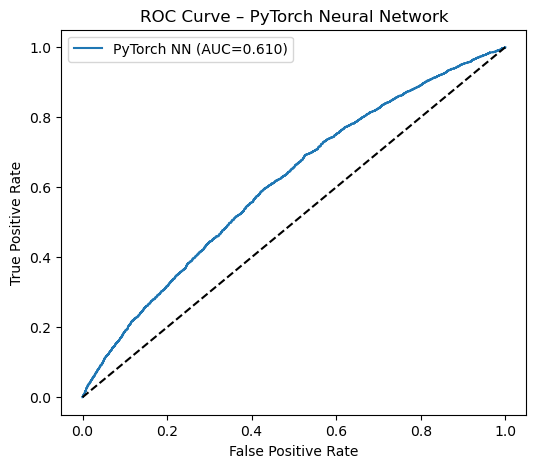

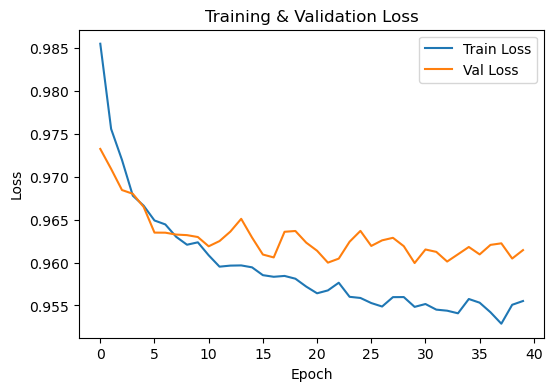

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

# ------------------------------
# 1️⃣ Tensor'a çevirme
# ------------------------------
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# 2️⃣ Model Tanımı
# ------------------------------
class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),

            nn.Linear(16, 1),
            
        )
        
    def forward(self, x):
        return self.model(x)

input_dim = X_svd_df.shape[1]
model = ChurnNN(input_dim)

# ------------------------------
# 3️⃣ Loss & Optimizer
# ------------------------------
pos_weight = torch.tensor(
    (y_train == 0).sum() / (y_train == 1).sum()
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------------
# 4️⃣ Eğitim Döngüsü
# ------------------------------
epochs = 50
patience = 10
best_loss = float('inf')
trigger_times = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Validation Loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            val_output = model(xb)
            loss = criterion(val_output, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_loss:.4f}")
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        trigger_times = 0
        best_model_wts = model.state_dict()
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# En iyi ağırlıkları yükle
model.load_state_dict(best_model_wts)

# ------------------------------
# 5️⃣ Tahmin & Performans
# ------------------------------
model.eval()
with torch.no_grad():
    y_prob = torch.sigmoid(model(X_test_tensor)).numpy().ravel()
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
best_threshold = thresholds[(tpr - fpr).argmax()]

y_pred = (y_prob > best_threshold).astype(int)


accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n🔹 PyTorch NN Sonuçları:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

# ROC Eğrisi
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"PyTorch NN (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve – PyTorch Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ------------------------------
# 6️⃣ Loss Grafiği
# ------------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()
